# VQE Default Calibration

This notebook is for choosing **robust VQE defaults**, not one-off best-case settings.

It sweeps a compact grid over:

- ansatz choice
- optimizer choice
- stepsize
- total step budget
- random seed

and compares results against the exact qubit-Hamiltonian ground energy.

Use the final recommendation table to decide whether `run_vqe(...)` defaults should change.

## How To Use This Notebook

- Treat the grids in the next cell as the only inputs you should edit.
- Keep at least two molecules and multiple seeds when deciding repo defaults.
- Prefer settings that are robust across molecules before preferring tiny final-energy improvements on one system.
- Use the final `recommended_defaults` table as the candidate source for code-default updates.


In [ ]:
from __future__ import annotations

import time
from contextlib import redirect_stdout
from io import StringIO
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display

from common.hamiltonian import build_hamiltonian
from vqe import run_vqe, OPTIMIZERS, ANSATZES

MOLECULE_SPECS = [
    {"molecule": "H2", "mapping": "jordan_wigner"},
    {
        "molecule": "LiH",
        "mapping": "jordan_wigner",
        "active_electrons": 2,
        "active_orbitals": 2,
    },
]

STEPSIZES = [0.01, 0.05, 0.10, 0.15, 0.2]
STEP_BUDGETS = [75]
SEEDS = [0, 1, 2]


def timed_call(fn, /, **kwargs):
    t0 = time.perf_counter()
    sink = StringIO()
    with redirect_stdout(sink):
        result = fn(**kwargs)
    return result, time.perf_counter() - t0


def exact_ground(spec):
    H, _, _ = build_hamiltonian(**spec)
    mat = np.asarray(qml.matrix(H), dtype=complex)
    return float(np.min(np.linalg.eigvalsh(mat)).real)


def stats(xs):
    arr = np.asarray(xs, dtype=float)
    return {
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "min": float(arr.min()),
        "max": float(arr.max()),
    }


EXACT = {spec["molecule"]: exact_ground(spec) for spec in MOLECULE_SPECS}
TOTAL_RUNS = (
    len(MOLECULE_SPECS)
    * len(ANSATZES)
    * len(OPTIMIZERS)
    * len(STEPSIZES)
    * len(STEP_BUDGETS)
    * len(SEEDS)
)
PROGRESS_EVERY = max(1, TOTAL_RUNS // 12)


In [15]:
records = []
run_index = 0


for spec in MOLECULE_SPECS:
    shared = dict(spec)
    molecule = shared["molecule"]
    exact_e0 = EXACT[molecule]

    for ansatz in ANSATZES:
        for optimizer in OPTIMIZERS:
            for stepsize in STEPSIZES:
                for steps in STEP_BUDGETS:
                    for seed in SEEDS:
                        run_index += 1
                        if run_index == 1 or run_index % PROGRESS_EVERY == 0 or run_index == TOTAL_RUNS:
                            print(
                                f"[{run_index}/{TOTAL_RUNS}] "
                                f"{molecule} | ansatz={ansatz} | opt={optimizer} | "
                                f"stepsize={stepsize} | steps={steps} | seed={seed}"
                            )
                        result, runtime_s = timed_call(
                            run_vqe,
                            **shared,
                            ansatz_name=ansatz,
                            optimizer_name=optimizer,
                            steps=steps,
                            stepsize=stepsize,
                            seed=seed,
                            noisy=False,
                            plot=False,
                            force=False,
                        )
                        records.append(
                            {
                                "molecule": molecule,
                                "ansatz": ansatz,
                                "optimizer": optimizer,
                                "stepsize": float(stepsize),
                                "steps": int(steps),
                                "seed": int(seed),
                                "energy": float(result["energy"]),
                                "abs_error": abs(float(result["energy"]) - exact_e0),
                                "runtime_s": float(runtime_s),
                                "num_qubits": int(result["num_qubits"]),
                                "param_count": int(np.asarray(result["final_params"]).size),
                            }
                        )

records_df = pd.DataFrame(records)
print(f"Completed {len(records_df)} VQE calibration runs.")
display(records_df.head(10).round(6))


[1/180] H2 | ansatz=UCCSD | opt=Adam | stepsize=0.01 | steps=75 | seed=0


[15/180] H2 | ansatz=UCCSD | opt=Adam | stepsize=0.2 | steps=75 | seed=2
[30/180] H2 | ansatz=UCCSD | opt=GradientDescent | stepsize=0.2 | steps=75 | seed=2
[45/180] H2 | ansatz=UCCSD | opt=Momentum | stepsize=0.2 | steps=75 | seed=2
[60/180] H2 | ansatz=UCCSD | opt=NesterovMomentum | stepsize=0.2 | steps=75 | seed=2
[75/180] H2 | ansatz=UCCSD | opt=RMSProp | stepsize=0.2 | steps=75 | seed=2
[90/180] H2 | ansatz=UCCSD | opt=Adagrad | stepsize=0.2 | steps=75 | seed=2
[105/180] LiH | ansatz=UCCSD | opt=Adam | stepsize=0.2 | steps=75 | seed=2
[120/180] LiH | ansatz=UCCSD | opt=GradientDescent | stepsize=0.2 | steps=75 | seed=2
[135/180] LiH | ansatz=UCCSD | opt=Momentum | stepsize=0.2 | steps=75 | seed=2
[150/180] LiH | ansatz=UCCSD | opt=NesterovMomentum | stepsize=0.2 | steps=75 | seed=2
[165/180] LiH | ansatz=UCCSD | opt=RMSProp | stepsize=0.2 | steps=75 | seed=2
[180/180] LiH | ansatz=UCCSD | opt=Adagrad | stepsize=0.2 | steps=75 | seed=2
Completed 180 VQE calibration runs.


,molecule,ansatz,optimizer,stepsize,steps,seed,energy,abs_error,runtime_s,num_qubits,param_count
0,H2,UCCSD,Adam,0.01,75,0,-1.137260,0.000010,2.586259,4,3
1,H2,UCCSD,Adam,0.01,75,1,-1.137260,0.000010,2.157871,4,3
2,H2,UCCSD,Adam,0.01,75,2,-1.137260,0.000010,2.160939,4,3
3,H2,UCCSD,Adam,0.05,75,0,-1.137264,0.000007,0.106564,4,3
4,H2,UCCSD,Adam,0.05,75,1,-1.137264,0.000007,0.153423,4,3
5,H2,UCCSD,Adam,0.05,75,2,-1.137264,0.000007,0.116033,4,3
6,H2,UCCSD,Adam,0.10,75,0,-1.137267,0.000003,0.068244,4,3
7,H2,UCCSD,Adam,0.10,75,1,-1.137267,0.000003,0.035663,4,3
8,H2,UCCSD,Adam,0.10,75,2,-1.137267,0.000003,0.056112,4,3
9,H2,UCCSD,Adam,0.15,75,0,-1.137268,0.000002,0.035177,4,3


In [16]:
grouped = defaultdict(list)
for row in records:
    key = (
        row["molecule"],
        row["ansatz"],
        row["optimizer"],
        row["stepsize"],
        row["steps"],
    )
    grouped[key].append(row)

summary = []
for key, rows in sorted(grouped.items()):
    energies = [r["energy"] for r in rows]
    errors = [r["abs_error"] for r in rows]
    runtimes = [r["runtime_s"] for r in rows]
    summary.append(
        {
            "molecule": key[0],
            "ansatz": key[1],
            "optimizer": key[2],
            "stepsize": key[3],
            "steps": key[4],
            "mean_abs_error": stats(errors)["mean"],
            "std_abs_error": stats(errors)["std"],
            "mean_energy": stats(energies)["mean"],
            "mean_runtime_s": stats(runtimes)["mean"],
            "score": stats(errors)["mean"] + 0.25 * stats(errors)["std"] + 0.001 * stats(runtimes)["mean"],
        }
    )

summary_df = pd.DataFrame(summary).sort_values(["molecule", "score", "mean_abs_error", "mean_runtime_s"])
display(summary_df.round(8))


,molecule,ansatz,optimizer,stepsize,steps,mean_abs_error,std_abs_error,mean_energy,mean_runtime_s,score
8,H2,UCCSD,Adam,0.15,75,2.230000e-06,0.0,-1.137268,0.036146,0.000038
25,H2,UCCSD,RMSProp,0.01,75,4.590000e-06,0.0,-1.137266,0.035104,0.000040
7,H2,UCCSD,Adam,0.10,75,3.500000e-06,0.0,-1.137267,0.053340,0.000057
6,H2,UCCSD,Adam,0.05,75,6.530000e-06,0.0,-1.137264,0.125340,0.000132
9,H2,UCCSD,Adam,0.20,75,2.610000e-06,0.0,-1.137268,0.150189,0.000153
26,H2,UCCSD,RMSProp,0.05,75,3.838700e-04,0.0,-1.136886,0.036605,0.000420
2,H2,UCCSD,Adagrad,0.10,75,0.000000e+00,0.0,-1.137270,1.431664,0.001432
12,H2,UCCSD,GradientDescent,0.10,75,8.000000e-08,0.0,-1.137270,1.461535,0.001462
24,H2,UCCSD,NesterovMomentum,0.20,75,0.000000e+00,0.0,-1.137270,1.472995,0.001473
17,H2,UCCSD,Momentum,0.10,75,4.840000e-06,0.0,-1.137265,1.513210,0.001518


In [17]:
best_per_molecule = {}
for molecule in sorted({row["molecule"] for row in summary}):
    rows = [row for row in summary if row["molecule"] == molecule]
    rows = sorted(rows, key=lambda row: (row["score"], row["mean_abs_error"], row["mean_runtime_s"]))
    best_per_molecule[molecule] = pd.DataFrame(rows[:10])

for molecule, df in best_per_molecule.items():
    print(f"Top VQE settings for {molecule}")
    display(df.round(8))


Top VQE settings for H2


,molecule,ansatz,optimizer,stepsize,steps,mean_abs_error,std_abs_error,mean_energy,mean_runtime_s,score
0,H2,UCCSD,Adam,0.15,75,2.230000e-06,0.0,-1.137268,0.036146,0.000038
1,H2,UCCSD,RMSProp,0.01,75,4.590000e-06,0.0,-1.137266,0.035104,0.000040
2,H2,UCCSD,Adam,0.10,75,3.500000e-06,0.0,-1.137267,0.053340,0.000057
3,H2,UCCSD,Adam,0.05,75,6.530000e-06,0.0,-1.137264,0.125340,0.000132
4,H2,UCCSD,Adam,0.20,75,2.610000e-06,0.0,-1.137268,0.150189,0.000153
5,H2,UCCSD,RMSProp,0.05,75,3.838700e-04,0.0,-1.136886,0.036605,0.000420
6,H2,UCCSD,Adagrad,0.10,75,0.000000e+00,0.0,-1.137270,1.431664,0.001432
7,H2,UCCSD,GradientDescent,0.10,75,8.000000e-08,0.0,-1.137270,1.461535,0.001462
8,H2,UCCSD,NesterovMomentum,0.20,75,0.000000e+00,0.0,-1.137270,1.472995,0.001473
9,H2,UCCSD,Momentum,0.10,75,4.840000e-06,0.0,-1.137265,1.513210,0.001518


Top VQE settings for LiH


,molecule,ansatz,optimizer,stepsize,steps,mean_abs_error,std_abs_error,mean_energy,mean_runtime_s,score
0,LiH,UCCSD,RMSProp,0.01,75,7.920000e-06,0.0,-7.862121,1.005305,0.001013
1,LiH,UCCSD,RMSProp,0.05,75,2.127000e-04,0.0,-7.861916,1.146136,0.001359
2,LiH,UCCSD,RMSProp,0.10,75,7.098000e-04,0.0,-7.861419,0.975430,0.001685
3,LiH,UCCSD,RMSProp,0.15,75,1.527650e-03,0.0,-7.860601,1.022694,0.002550
4,LiH,UCCSD,Adam,0.20,75,1.460000e-06,0.0,-7.862127,2.809735,0.002811
5,LiH,UCCSD,GradientDescent,0.10,75,8.930000e-06,0.0,-7.862120,2.825587,0.002835
6,LiH,UCCSD,Adam,0.10,75,3.200000e-07,0.0,-7.862129,2.838190,0.002839
7,LiH,UCCSD,Momentum,0.20,75,5.000000e-08,0.0,-7.862129,2.844522,0.002845
8,LiH,UCCSD,Adagrad,0.10,75,0.000000e+00,0.0,-7.862129,2.874892,0.002875
9,LiH,UCCSD,NesterovMomentum,0.20,75,0.000000e+00,0.0,-7.862129,2.926576,0.002927


## How To Interpret The Results

- `best_per_molecule` shows the strongest settings for each benchmark molecule.
- `recommended_defaults` intentionally aggregates only the chemistry-baseline ansatz (`UCCSD`) so the final recommendation stays realistic for the package defaults.
- The notebook score favors low absolute error first, then stability across seeds, then runtime.


In [18]:
recommended_defaults = []
candidate_rows = [row for row in summary if row["ansatz"] == "UCCSD"]
if candidate_rows:
    by_setting = defaultdict(list)
    for row in candidate_rows:
        by_setting[(row["optimizer"], row["stepsize"], row["steps"])].append(row)

    aggregate = []
    for key, rows in sorted(by_setting.items()):
        aggregate.append(
            {
                "optimizer": key[0],
                "stepsize": key[1],
                "steps": key[2],
                "mean_abs_error": float(np.mean([row["mean_abs_error"] for row in rows])),
                "mean_std_abs_error": float(np.mean([row["std_abs_error"] for row in rows])),
                "mean_runtime_s": float(np.mean([row["mean_runtime_s"] for row in rows])),
            }
        )
    aggregate = sorted(
        aggregate,
        key=lambda row: (row["mean_abs_error"] + 0.25 * row["mean_std_abs_error"] + 0.001 * row["mean_runtime_s"], row["mean_abs_error"]),
    )
    recommended_defaults = aggregate[:10]

recommended_defaults_df = pd.DataFrame(recommended_defaults)
print("Recommended VQE default candidates (UCCSD-only aggregate)")
display(recommended_defaults_df.round(8))


Recommended VQE default candidates (UCCSD-only aggregate)


,optimizer,stepsize,steps,mean_abs_error,mean_std_abs_error,mean_runtime_s
0,RMSProp,0.01,75,0.000006,0.0,0.520204
1,RMSProp,0.05,75,0.000298,0.0,0.591371
2,Adam,0.10,75,0.000002,0.0,1.445765
3,Adam,0.20,75,0.000002,0.0,1.479962
4,Adam,0.15,75,0.000001,0.0,1.884416
5,RMSProp,0.10,75,0.001381,0.0,0.506977
6,Adam,0.05,75,0.000003,0.0,1.927539
7,GradientDescent,0.10,75,0.000005,0.0,2.143561
8,Adagrad,0.10,75,0.000000,0.0,2.153278
9,NesterovMomentum,0.20,75,0.000000,0.0,2.199786


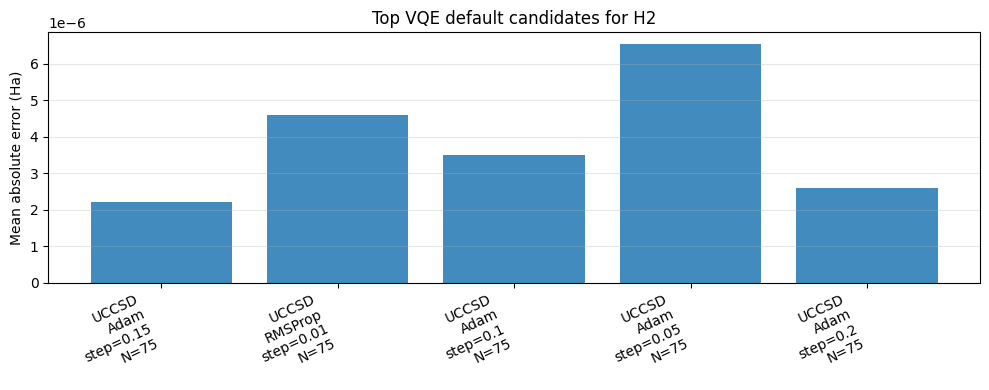

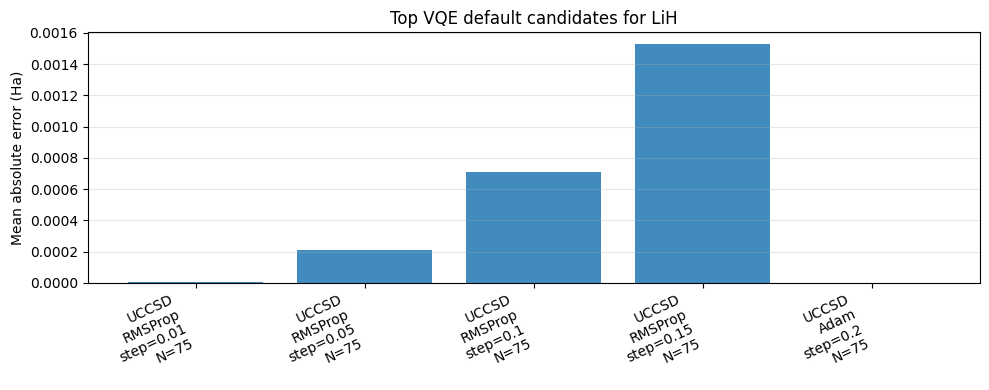

In [19]:
for molecule in sorted(best_per_molecule):
    rows = best_per_molecule[molecule].head(5).to_dict("records")
    labels = [f"{row['ansatz']}\n{row['optimizer']}\nstep={row['stepsize']}\nN={row['steps']}" for row in rows]
    values = [row["mean_abs_error"] for row in rows]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values, alpha=0.85)
    plt.ylabel("Mean absolute error (Ha)")
    plt.title(f"Top VQE default candidates for {molecule}")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()